In [1]:
from prediction import predict_flights
from prediction import get_top_flights
from prediction import apply_business_rules
from routing import valid_route
from data_processing import prepare_features
from routing import get_feasible_flights


In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [3]:
from sklearn.metrics import accuracy_score, classification_report

In [4]:
shipment_df = pd.read_csv("shipment_dataset(JAN+FEB+MAR).csv")

schedule_df = pd.read_csv("flight_schedule_dataset.csv")

routes_df = pd.read_csv("flight_routes_dataset.csv")

capacity_df = pd.read_csv("flight_capacity_dataset.csv")

C:\Users\9797487\AppData\Local\Temp\ipykernel_13936\693577506.py:1: DtypeWarning: Columns (3,4,5,7,8,10,11,12,13,14,15,16,21,22,25) have mixed types. Specify dtype option on import or set low_memory=False.
  shipment_df = pd.read_csv("shipment_dataset(JAN+FEB+MAR).csv")


In [5]:
routes_df["Origin"] = routes_df["Origin"].str.strip()
routes_df["Destination"] = routes_df["Destination"].str.strip()

In [6]:
day_map_num = {
    "Monday":1,
    "Tuesday":2,
    "Wednesday":3,
    "Thursday":4,
    "Friday":5,
    "Saturday":6,
    "Sunday":7
}

capacity_df["Takeoff_Weekday"] = capacity_df["Day_of_Week"].astype(str).str.strip().map(day_map_num)

print("DEBUG:", capacity_df.columns)

DEBUG: Index(['Flight_Number', 'Day_of_Week', 'Capacity_KG', 'Takeoff_Weekday'], dtype='object')


In [7]:
capacity_df["Loaded_So_Far"] = 0  # New column to track loaded capacity
capacity_df["Remaining_Capacity"] = capacity_df["Capacity_KG"]  # New column to track remaining capacity
capacity_df["Load_Percentage"] = 0 # New column to track load percentage

capacity_df["Loaded_Volume"] = 0.0  # New column to track loaded volume

if "Capacity_Volume" not in capacity_df.columns:
    capacity_df["Capacity_Volume"] = capacity_df["Capacity_KG"]  # Assuming 1 KG = 1 Volume unit for simplicity

In [8]:
print("final capacity columns:", capacity_df.columns)

final capacity columns: Index(['Flight_Number', 'Day_of_Week', 'Capacity_KG', 'Takeoff_Weekday',
       'Loaded_So_Far', 'Remaining_Capacity', 'Load_Percentage',
       'Loaded_Volume', 'Capacity_Volume'],
      dtype='object')


In [9]:
capacity_df["Loaded_So_Far"] = capacity_df["Loaded_So_Far"].astype(float)  # Ensure this column is float for calculations
capacity_df["Capacity_KG"] = capacity_df["Capacity_KG"].astype(float)
capacity_df["Loaded_Volume"] = capacity_df["Loaded_Volume"].astype(float)  
capacity_df["Capacity_Volume"] = capacity_df["Capacity_Volume"].astype(float)  
# Ensure this column is float for calculations

In [10]:
schedule_df["Operating_Day"] = schedule_df["Operating_Day"].str.strip()

In [11]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Unnamed: 6,Split,Flight_Number,Unnamed: 9,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,Unnamed: 25,L,B,H,Volume
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104623,8.701063e+11,1.0,5.0,NaN,Small,IE,NaN,MEM,BA 138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,5.000000,NaN,NaN,NaN,NaN,1.495000
104624,8.701092e+11,9.0,33.0,NaN,Small,IE,NaN,MEM,BA 138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,3.666667,NaN,NaN,NaN,NaN,13.455000
104625,8.701006e+11,6.0,60.0,NaN,Medium,IE,NaN,MEM,BA 138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,10.000000,NaN,NaN,NaN,NaN,8.970000
104626,8.700777e+11,15.0,85.0,NaN,Medium,IE,NaN,MEM,BA 138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,5.666667,NaN,NaN,NaN,NaN,22.425000


In [12]:
schedule_df

,Flight_Number,Airline,Operating_Day,Takeoff_Weekday
0,AI 179,AI,Monday,1
1,AI 179,AI,Tuesday,2
2,AI 179,AI,Friday,5
3,AI 179,AI,Saturday,6
4,QR 557,QR,Tuesday,2
5,QR 557,QR,Wednesday,3
6,QR 557,QR,Thursday,4
7,QR 557,QR,Friday,5
8,QR 557,QR,Saturday,6
9,QR 557,QR,Sunday,7


In [13]:
routes_df

,Flight_Number,Origin,Destination,Route_Type
0,6E 021,BOM,CDG,Direct
1,EK 507,BOM,DXB,Direct
2,EK 507,DXB,CDG,Hub
3,EK 507,DXB,MEM,Hub
4,EK 507,DXB,LHR,Hub
5,QR 557,BOM,MEM,Direct
6,AI 179,BOM,MEM,Direct


In [14]:
capacity_df

,Flight_Number,Day_of_Week,Capacity_KG,Takeoff_Weekday,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Loaded_Volume,Capacity_Volume
0,EK 507,Sunday,4950.0,7,0.0,4950,0,0.0,4950.0
1,AI 179,Monday,8250.0,1,0.0,8250,0,0.0,8250.0
2,AI 179,Tuesday,8250.0,2,0.0,8250,0,0.0,8250.0
3,AI 179,Friday,8250.0,5,0.0,8250,0,0.0,8250.0
4,AI 179,Saturday,8250.0,6,0.0,8250,0,0.0,8250.0
5,QR 557,Tuesday,4950.0,2,0.0,4950,0,0.0,4950.0
6,QR 557,Wednesday,4950.0,3,0.0,4950,0,0.0,4950.0
7,QR 557,Thursday,4950.0,4,0.0,4950,0,0.0,4950.0
8,QR 557,Friday,4950.0,5,0.0,4950,0,0.0,4950.0
9,QR 557,Saturday,3300.0,6,0.0,3300,0,0.0,3300.0


In [15]:
print(shipment_df.shape)
print(schedule_df.shape)
print(routes_df.shape)
print(capacity_df.shape)

(104628, 30)
(17, 4)
(7, 4)
(17, 9)


In [16]:
shipment_df = shipment_df.dropna(how="all") # Drop rows where all elements are NaN

In [17]:
def normalize_flight(f):
    return str(f).replace(" ", "").strip()

# Apply everywhere
shipment_df["Flight_Number"] = shipment_df["Flight_Number"].apply(normalize_flight)

schedule_df["Flight_Number"] = schedule_df["Flight_Number"].apply(normalize_flight)

capacity_df["Flight_Number"] = capacity_df["Flight_Number"].apply(normalize_flight)

routes_df["Flight_Number"] = routes_df["Flight_Number"].apply(normalize_flight)

C:\Users\9797487\AppData\Local\Temp\ipykernel_13936\3819440407.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shipment_df["Flight_Number"] = shipment_df["Flight_Number"].apply(normalize_flight)


In [18]:
shipment_df.head()

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Unnamed: 6,Split,Flight_Number,Unnamed: 9,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,Unnamed: 25,L,B,H,Volume
164,8.881149e+11,1.0,3.5,"10,524.31",Small,IE,NaN,MEM,QR557,NaN,1/23/2026,Thursday,23-01-2026,23-01-2026,2/2/2026,1/25/2026,QR,Friday,3.0,11.0,8.0,Direct,MEM,4.0,3.5,11 15 4,11.0,15.0,4.0,0.11
175,8.882286e+11,1.0,74.5,"2,18,548.260",Medium,IEF,NaN,MEM,QR557,NaN,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,1/30/2026,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,74.5,32 25 22,32.0,25.0,22.0,2.93
176,8.881562e+11,1.0,131.0,"1,00,945.260",Medium,IEF,NaN,MEM,QR557,NaN,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,1/30/2026,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,131.0,27 23 20,27.0,23.0,20.0,2.07
193,8.882674e+11,1.0,26.0,"63,234.44",Small,IE,NaN,MEM,QR557,NaN,1/28/2026,Wednesday,28-01-2026,29-01-2026,2/6/2026,1/31/2026,QR,Thursday,3.0,9.0,6.0,Direct,MEM,3.0,26.0,16 20 6,16.0,20.0,6.0,0.32
195,8.883042e+11,2.0,8.0,"42,149.13",Small,IE,NaN,MEM,QR557,NaN,1/29/2026,Thursday,30-01-2026,30-01-2026,2/9/2026,2/3/2026,QR,Friday,5.0,11.0,6.0,Direct,MEM,4.0,4.0,36 25 14,36.0,25.0,14.0,4.20


In [19]:
shipment_df = shipment_df.dropna(subset=["Weight"]) # Drop rows where 'Weight' is NaN

In [20]:
shipment_df = shipment_df.drop(columns=["Unnamed: 6", "Unnamed: 25","Unnamed: 9"], errors="ignore") # Drop unnecessary columns if they exist

In [21]:
shipment_df.head()

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,L,B,H,Volume
164,8.881149e+11,1.0,3.5,"10,524.31",Small,IE,MEM,QR557,1/23/2026,Thursday,23-01-2026,23-01-2026,2/2/2026,1/25/2026,QR,Friday,3.0,11.0,8.0,Direct,MEM,4.0,3.5,11.0,15.0,4.0,0.11
175,8.882286e+11,1.0,74.5,"2,18,548.260",Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,1/30/2026,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,74.5,32.0,25.0,22.0,2.93
176,8.881562e+11,1.0,131.0,"1,00,945.260",Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,1/30/2026,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,131.0,27.0,23.0,20.0,2.07
193,8.882674e+11,1.0,26.0,"63,234.44",Small,IE,MEM,QR557,1/28/2026,Wednesday,28-01-2026,29-01-2026,2/6/2026,1/31/2026,QR,Thursday,3.0,9.0,6.0,Direct,MEM,3.0,26.0,16.0,20.0,6.0,0.32
195,8.883042e+11,2.0,8.0,"42,149.13",Small,IE,MEM,QR557,1/29/2026,Thursday,30-01-2026,30-01-2026,2/9/2026,2/3/2026,QR,Friday,5.0,11.0,6.0,Direct,MEM,4.0,4.0,36.0,25.0,14.0,4.20


In [22]:
shipment_df["Weight"] = shipment_df["Weight"].astype(str).str.replace(",","") # Remove commas from the 'Weight' column and convert to numeric
shipment_df["Weight"] = pd.to_numeric(shipment_df["Weight"], errors="coerce")

In [23]:
shipment_df["Invoice Value"] = shipment_df["Invoice Value"].astype(str).str.replace(",","")
shipment_df["Invoice Value"] = pd.to_numeric(shipment_df["Invoice Value"], errors="coerce") 

In [24]:
shipment_df["L"] = pd.to_numeric(shipment_df["L"], errors="coerce") 
shipment_df["B"] = pd.to_numeric(shipment_df["B"], errors="coerce")
shipment_df["H"] = pd.to_numeric(shipment_df["H"], errors="coerce")
shipment_df["Volume"] = pd.to_numeric(shipment_df["Volume"], errors="coerce")# Ensure 'Volume' is numeric, coercing errors to NaN


In [25]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,L,B,H,Volume
164,8.881149e+11,1.0,3.5,10524.31,Small,IE,MEM,QR557,1/23/2026,Thursday,23-01-2026,23-01-2026,2/2/2026,1/25/2026,QR,Friday,3.0,11.0,8.0,Direct,MEM,4.0,3.500000,11.0,15.0,4.0,0.110000
175,8.882286e+11,1.0,74.5,218548.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,1/30/2026,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,74.500000,32.0,25.0,22.0,2.930000
176,8.881562e+11,1.0,131.0,100945.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,1/30/2026,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,131.000000,27.0,23.0,20.0,2.070000
193,8.882674e+11,1.0,26.0,63234.44,Small,IE,MEM,QR557,1/28/2026,Wednesday,28-01-2026,29-01-2026,2/6/2026,1/31/2026,QR,Thursday,3.0,9.0,6.0,Direct,MEM,3.0,26.000000,16.0,20.0,6.0,0.320000
195,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR557,1/29/2026,Thursday,30-01-2026,30-01-2026,2/9/2026,2/3/2026,QR,Friday,5.0,11.0,6.0,Direct,MEM,4.0,4.000000,36.0,25.0,14.0,4.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104623,8.701063e+11,1.0,5.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,5.000000,NaN,NaN,NaN,1.495000
104624,8.701092e+11,9.0,33.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,3.666667,NaN,NaN,NaN,13.455000
104625,8.701006e+11,6.0,60.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,10.000000,NaN,NaN,NaN,8.970000
104626,8.700777e+11,15.0,85.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,5.666667,NaN,NaN,NaN,22.425000


In [26]:
shipment_df.isnull().sum() #checking for any remaining null values

AWB                                                     0
Pieces                                                  0
Weight                                                  0
Invoice Value                                        1533
Weight_Category                                         0
Service                                                 0
Split                                                   0
Flight_Number                                           0
Shipment Pickup Date                                 1533
Shipment Pickup_DOW                                  1533
Shipment received date by the CLH team               1533
Shipment Handover date to Ramp by the CLH Team       1533
Commit Date                                          1533
ALH FIRST DATE(Flight takeoff from BOM)              1533
Airline_Code                                         1533
Shipment handover day to the ramp                    1533
NO.Of Days between Pickup Date and Flight Takeoff       0
Delivery_Windo

In [27]:
shipment_df["ALH FIRST DATE(Flight takeoff from BOM)"] = pd.to_datetime(
    shipment_df["ALH FIRST DATE(Flight takeoff from BOM)"],
    errors="coerce"
)

In [28]:
shipment_df["Takeoff_Weekday"] = shipment_df[
    "ALH FIRST DATE(Flight takeoff from BOM)"
].dt.weekday + 1 # Monday=1, Sunday=7

In [29]:
#shipment_df = shipment_df.dropna() # Drop any remaining rows with NaN values after conversion

In [30]:
def urgency_level(x):

    if x <= 4:
        return "Critical"
    elif x <= 6:
        return "High"
    elif x <= 8:
        return "Medium"
    else:
        return "Low"

shipment_df["Urgency_Level"] = shipment_df["Delivery_Window"].apply(urgency_level)

In [31]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,L,B,H,Volume,Takeoff_Weekday,Urgency_Level
164,8.881149e+11,1.0,3.5,10524.31,Small,IE,MEM,QR557,1/23/2026,Thursday,23-01-2026,23-01-2026,2/2/2026,2026-01-25,QR,Friday,3.0,11.0,8.0,Direct,MEM,4.0,3.500000,11.0,15.0,4.0,0.110000,7.0,Low
175,8.882286e+11,1.0,74.5,218548.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,74.500000,32.0,25.0,22.0,2.930000,5.0,Low
176,8.881562e+11,1.0,131.0,100945.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,131.000000,27.0,23.0,20.0,2.070000,5.0,Low
193,8.882674e+11,1.0,26.0,63234.44,Small,IE,MEM,QR557,1/28/2026,Wednesday,28-01-2026,29-01-2026,2/6/2026,2026-01-31,QR,Thursday,3.0,9.0,6.0,Direct,MEM,3.0,26.000000,16.0,20.0,6.0,0.320000,6.0,Low
195,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR557,1/29/2026,Thursday,30-01-2026,30-01-2026,2/9/2026,2026-02-03,QR,Friday,5.0,11.0,6.0,Direct,MEM,4.0,4.000000,36.0,25.0,14.0,4.200000,2.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104623,8.701063e+11,1.0,5.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,5.000000,NaN,NaN,NaN,1.495000,NaN,Medium
104624,8.701092e+11,9.0,33.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,3.666667,NaN,NaN,NaN,13.455000,NaN,Medium
104625,8.701006e+11,6.0,60.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,10.000000,NaN,NaN,NaN,8.970000,NaN,Low
104626,8.700777e+11,15.0,85.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,5.666667,NaN,NaN,NaN,22.425000,NaN,Low


In [32]:
#shipment_df = shipment_df[
#    shipment_df["NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE"] > 0
#]

In [33]:
#shipment_df["Weekend_Pickup"] = shipment_df["Pickup Weekday Number"].apply(
#    lambda x: 1 if x >= 6 else 0
#)  # Create a binary feature for weekend pickups (1 for Saturday/Sunday, 0 for weekdays)

In [34]:
shipment_df["Service"] = shipment_df["Service"].str.upper()

priority_map = {
    "IP":1,
    "IPF":2,
    "IE":3,
    "IEF":4
}

shipment_df["Service_Priority"] = shipment_df["Service"].map(priority_map)

In [35]:
shipment_df["Flight_Number"] = shipment_df["Flight_Number"].str.strip()
shipment_df["Flight_Number"] = shipment_df["Flight_Number"].str.replace(r'\s+', ' ', regex=True)

In [36]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,L,B,H,Volume,Takeoff_Weekday,Urgency_Level,Service_Priority
164,8.881149e+11,1.0,3.5,10524.31,Small,IE,MEM,QR557,1/23/2026,Thursday,23-01-2026,23-01-2026,2/2/2026,2026-01-25,QR,Friday,3.0,11.0,8.0,Direct,MEM,4.0,3.500000,11.0,15.0,4.0,0.110000,7.0,Low,3
175,8.882286e+11,1.0,74.5,218548.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,74.500000,32.0,25.0,22.0,2.930000,5.0,Low,4
176,8.881562e+11,1.0,131.0,100945.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,131.000000,27.0,23.0,20.0,2.070000,5.0,Low,4
193,8.882674e+11,1.0,26.0,63234.44,Small,IE,MEM,QR557,1/28/2026,Wednesday,28-01-2026,29-01-2026,2/6/2026,2026-01-31,QR,Thursday,3.0,9.0,6.0,Direct,MEM,3.0,26.000000,16.0,20.0,6.0,0.320000,6.0,Low,3
195,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR557,1/29/2026,Thursday,30-01-2026,30-01-2026,2/9/2026,2026-02-03,QR,Friday,5.0,11.0,6.0,Direct,MEM,4.0,4.000000,36.0,25.0,14.0,4.200000,2.0,Low,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104623,8.701063e+11,1.0,5.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,5.000000,NaN,NaN,NaN,1.495000,NaN,Medium,3
104624,8.701092e+11,9.0,33.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,3.666667,NaN,NaN,NaN,13.455000,NaN,Medium,3
104625,8.701006e+11,6.0,60.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,10.000000,NaN,NaN,NaN,8.970000,NaN,Low,3
104626,8.700777e+11,15.0,85.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,5.666667,NaN,NaN,NaN,22.425000,NaN,Low,3


In [37]:
list(shipment_df.columns)

['AWB',
 'Pieces',
 'Weight',
 'Invoice Value',
 'Weight_Category',
 'Service',
 'Split',
 'Flight_Number',
 'Shipment Pickup Date',
 'Shipment Pickup_DOW',
 'Shipment received date by the CLH team',
 'Shipment Handover date to Ramp by the CLH Team',
 'Commit Date',
 'ALH FIRST DATE(Flight takeoff from BOM)',
 'Airline_Code',
 'Shipment handover day to the ramp',
 'NO.Of Days between Pickup Date and Flight Takeoff',
 'Delivery_Window',
 'NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE',
 'Route_Type',
 'Destination_Hub',
 'Pickup Weekday Number',
 'Weight per Piece',
 'L',
 'B',
 'H',
 'Volume',
 'Takeoff_Weekday',
 'Urgency_Level',
 'Service_Priority']

In [38]:
schedule_df

,Flight_Number,Airline,Operating_Day,Takeoff_Weekday
0,AI179,AI,Monday,1
1,AI179,AI,Tuesday,2
2,AI179,AI,Friday,5
3,AI179,AI,Saturday,6
4,QR557,QR,Tuesday,2
5,QR557,QR,Wednesday,3
6,QR557,QR,Thursday,4
7,QR557,QR,Friday,5
8,QR557,QR,Saturday,6
9,QR557,QR,Sunday,7


In [39]:
routes_df

,Flight_Number,Origin,Destination,Route_Type
0,6E021,BOM,CDG,Direct
1,EK507,BOM,DXB,Direct
2,EK507,DXB,CDG,Hub
3,EK507,DXB,MEM,Hub
4,EK507,DXB,LHR,Hub
5,QR557,BOM,MEM,Direct
6,AI179,BOM,MEM,Direct


In [40]:
capacity_df

,Flight_Number,Day_of_Week,Capacity_KG,Takeoff_Weekday,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Loaded_Volume,Capacity_Volume
0,EK507,Sunday,4950.0,7,0.0,4950,0,0.0,4950.0
1,AI179,Monday,8250.0,1,0.0,8250,0,0.0,8250.0
2,AI179,Tuesday,8250.0,2,0.0,8250,0,0.0,8250.0
3,AI179,Friday,8250.0,5,0.0,8250,0,0.0,8250.0
4,AI179,Saturday,8250.0,6,0.0,8250,0,0.0,8250.0
5,QR557,Tuesday,4950.0,2,0.0,4950,0,0.0,4950.0
6,QR557,Wednesday,4950.0,3,0.0,4950,0,0.0,4950.0
7,QR557,Thursday,4950.0,4,0.0,4950,0,0.0,4950.0
8,QR557,Friday,4950.0,5,0.0,4950,0,0.0,4950.0
9,QR557,Saturday,3300.0,6,0.0,3300,0,0.0,3300.0


In [41]:
shipment_df["Flight_Number"].unique()

array(['QR557', 'AI179', 'EK507', '6E021', 'QR8603', 'QR8605', 'BA138'],
      dtype=object)

In [42]:
shipment_df["Destination_Hub"].unique()

array(['MEM', 'CDG', 'DXB', 'LHR', nan], dtype=object)

In [43]:
shipment_df["Split"].unique()

array(['MEM', 'DXB', 'CDG', 'LHR'], dtype=object)

In [44]:
shipment_df.head()

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,L,B,H,Volume,Takeoff_Weekday,Urgency_Level,Service_Priority
164,8.881149e+11,1.0,3.5,10524.31,Small,IE,MEM,QR557,1/23/2026,Thursday,23-01-2026,23-01-2026,2/2/2026,2026-01-25,QR,Friday,3.0,11.0,8.0,Direct,MEM,4.0,3.5,11.0,15.0,4.0,0.11,7.0,Low,3
175,8.882286e+11,1.0,74.5,218548.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,74.5,32.0,25.0,22.0,2.93,5.0,Low,4
176,8.881562e+11,1.0,131.0,100945.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,131.0,27.0,23.0,20.0,2.07,5.0,Low,4
193,8.882674e+11,1.0,26.0,63234.44,Small,IE,MEM,QR557,1/28/2026,Wednesday,28-01-2026,29-01-2026,2/6/2026,2026-01-31,QR,Thursday,3.0,9.0,6.0,Direct,MEM,3.0,26.0,16.0,20.0,6.0,0.32,6.0,Low,3
195,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR557,1/29/2026,Thursday,30-01-2026,30-01-2026,2/9/2026,2026-02-03,QR,Friday,5.0,11.0,6.0,Direct,MEM,4.0,4.0,36.0,25.0,14.0,4.20,2.0,Low,3


In [45]:
capacity_df

,Flight_Number,Day_of_Week,Capacity_KG,Takeoff_Weekday,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Loaded_Volume,Capacity_Volume
0,EK507,Sunday,4950.0,7,0.0,4950,0,0.0,4950.0
1,AI179,Monday,8250.0,1,0.0,8250,0,0.0,8250.0
2,AI179,Tuesday,8250.0,2,0.0,8250,0,0.0,8250.0
3,AI179,Friday,8250.0,5,0.0,8250,0,0.0,8250.0
4,AI179,Saturday,8250.0,6,0.0,8250,0,0.0,8250.0
5,QR557,Tuesday,4950.0,2,0.0,4950,0,0.0,4950.0
6,QR557,Wednesday,4950.0,3,0.0,4950,0,0.0,4950.0
7,QR557,Thursday,4950.0,4,0.0,4950,0,0.0,4950.0
8,QR557,Friday,4950.0,5,0.0,4950,0,0.0,4950.0
9,QR557,Saturday,3300.0,6,0.0,3300,0,0.0,3300.0


In [46]:
shipment_df = shipment_df.merge(
capacity_df,
on=["Flight_Number","Takeoff_Weekday"],
how="left"
)

In [47]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,L,B,H,Volume,Takeoff_Weekday,Urgency_Level,Service_Priority,Day_of_Week,Capacity_KG,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Loaded_Volume,Capacity_Volume
0,8.881149e+11,1.0,3.5,10524.31,Small,IE,MEM,QR557,1/23/2026,Thursday,23-01-2026,23-01-2026,2/2/2026,2026-01-25,QR,Friday,3.0,11.0,8.0,Direct,MEM,4.0,3.500000,11.0,15.0,4.0,0.110000,7.0,Low,3,Sunday,1650.0,0.0,1650.0,0.0,0.0,1650.0
1,8.882286e+11,1.0,74.5,218548.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,74.500000,32.0,25.0,22.0,2.930000,5.0,Low,4,Friday,4950.0,0.0,4950.0,0.0,0.0,4950.0
2,8.881562e+11,1.0,131.0,100945.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,131.000000,27.0,23.0,20.0,2.070000,5.0,Low,4,Friday,4950.0,0.0,4950.0,0.0,0.0,4950.0
3,8.882674e+11,1.0,26.0,63234.44,Small,IE,MEM,QR557,1/28/2026,Wednesday,28-01-2026,29-01-2026,2/6/2026,2026-01-31,QR,Thursday,3.0,9.0,6.0,Direct,MEM,3.0,26.000000,16.0,20.0,6.0,0.320000,6.0,Low,3,Saturday,3300.0,0.0,3300.0,0.0,0.0,3300.0
4,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR557,1/29/2026,Thursday,30-01-2026,30-01-2026,2/9/2026,2026-02-03,QR,Friday,5.0,11.0,6.0,Direct,MEM,4.0,4.000000,36.0,25.0,14.0,4.200000,2.0,Low,3,Tuesday,4950.0,0.0,4950.0,0.0,0.0,4950.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2521,8.701063e+11,1.0,5.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,5.000000,NaN,NaN,NaN,1.495000,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2522,8.701092e+11,9.0,33.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,3.666667,NaN,NaN,NaN,13.455000,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2523,8.701006e+11,6.0,60.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,10.000000,NaN,NaN,NaN,8.970000,NaN,Low,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2524,8.700777e+11,15.0,85.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,5.666667,NaN,NaN,NaN,22.425000,NaN,Low,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
shipment_df.isnull().sum() #checking for any remaining null values

AWB                                                     0
Pieces                                                  0
Weight                                                  0
Invoice Value                                        1533
Weight_Category                                         0
Service                                                 0
Split                                                   0
Flight_Number                                           0
Shipment Pickup Date                                 1533
Shipment Pickup_DOW                                  1533
Shipment received date by the CLH team               1533
Shipment Handover date to Ramp by the CLH Team       1533
Commit Date                                          1533
ALH FIRST DATE(Flight takeoff from BOM)              1533
Airline_Code                                         1533
Shipment handover day to the ramp                    1533
NO.Of Days between Pickup Date and Flight Takeoff       0
Delivery_Windo

In [49]:
shipment_df["Flight_Number"].unique()

array(['QR557', 'AI179', 'EK507', '6E021', 'QR8603', 'QR8605', 'BA138'],
      dtype=object)

In [50]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,L,B,H,Volume,Takeoff_Weekday,Urgency_Level,Service_Priority,Day_of_Week,Capacity_KG,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Loaded_Volume,Capacity_Volume
0,8.881149e+11,1.0,3.5,10524.31,Small,IE,MEM,QR557,1/23/2026,Thursday,23-01-2026,23-01-2026,2/2/2026,2026-01-25,QR,Friday,3.0,11.0,8.0,Direct,MEM,4.0,3.500000,11.0,15.0,4.0,0.110000,7.0,Low,3,Sunday,1650.0,0.0,1650.0,0.0,0.0,1650.0
1,8.882286e+11,1.0,74.5,218548.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,74.500000,32.0,25.0,22.0,2.930000,5.0,Low,4,Friday,4950.0,0.0,4950.0,0.0,0.0,4950.0
2,8.881562e+11,1.0,131.0,100945.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,131.000000,27.0,23.0,20.0,2.070000,5.0,Low,4,Friday,4950.0,0.0,4950.0,0.0,0.0,4950.0
3,8.882674e+11,1.0,26.0,63234.44,Small,IE,MEM,QR557,1/28/2026,Wednesday,28-01-2026,29-01-2026,2/6/2026,2026-01-31,QR,Thursday,3.0,9.0,6.0,Direct,MEM,3.0,26.000000,16.0,20.0,6.0,0.320000,6.0,Low,3,Saturday,3300.0,0.0,3300.0,0.0,0.0,3300.0
4,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR557,1/29/2026,Thursday,30-01-2026,30-01-2026,2/9/2026,2026-02-03,QR,Friday,5.0,11.0,6.0,Direct,MEM,4.0,4.000000,36.0,25.0,14.0,4.200000,2.0,Low,3,Tuesday,4950.0,0.0,4950.0,0.0,0.0,4950.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2521,8.701063e+11,1.0,5.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,5.000000,NaN,NaN,NaN,1.495000,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2522,8.701092e+11,9.0,33.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,3.666667,NaN,NaN,NaN,13.455000,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2523,8.701006e+11,6.0,60.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,10.000000,NaN,NaN,NaN,8.970000,NaN,Low,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2524,8.700777e+11,15.0,85.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,5.666667,NaN,NaN,NaN,22.425000,NaN,Low,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
shipment_df["Capacity_Ratio"] = shipment_df["Weight"] /shipment_df["Capacity_KG"] # Create a new feature representing the ratio of shipment weight to flight capacity
# % of flight capacity used by the shipment

In [52]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,ALH FIRST DATE(Flight takeoff from BOM),Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,L,B,H,Volume,Takeoff_Weekday,Urgency_Level,Service_Priority,Day_of_Week,Capacity_KG,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Loaded_Volume,Capacity_Volume,Capacity_Ratio
0,8.881149e+11,1.0,3.5,10524.31,Small,IE,MEM,QR557,1/23/2026,Thursday,23-01-2026,23-01-2026,2/2/2026,2026-01-25,QR,Friday,3.0,11.0,8.0,Direct,MEM,4.0,3.500000,11.0,15.0,4.0,0.110000,7.0,Low,3,Sunday,1650.0,0.0,1650.0,0.0,0.0,1650.0,0.002121
1,8.882286e+11,1.0,74.5,218548.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,74.500000,32.0,25.0,22.0,2.930000,5.0,Low,4,Friday,4950.0,0.0,4950.0,0.0,0.0,4950.0,0.015051
2,8.881562e+11,1.0,131.0,100945.26,Medium,IEF,MEM,QR557,1/27/2026,Tuesday,27-01-2026,28-01-2026,2/6/2026,2026-01-30,QR,Wednesday,3.0,10.0,7.0,Direct,MEM,2.0,131.000000,27.0,23.0,20.0,2.070000,5.0,Low,4,Friday,4950.0,0.0,4950.0,0.0,0.0,4950.0,0.026465
3,8.882674e+11,1.0,26.0,63234.44,Small,IE,MEM,QR557,1/28/2026,Wednesday,28-01-2026,29-01-2026,2/6/2026,2026-01-31,QR,Thursday,3.0,9.0,6.0,Direct,MEM,3.0,26.000000,16.0,20.0,6.0,0.320000,6.0,Low,3,Saturday,3300.0,0.0,3300.0,0.0,0.0,3300.0,0.007879
4,8.883042e+11,2.0,8.0,42149.13,Small,IE,MEM,QR557,1/29/2026,Thursday,30-01-2026,30-01-2026,2/9/2026,2026-02-03,QR,Friday,5.0,11.0,6.0,Direct,MEM,4.0,4.000000,36.0,25.0,14.0,4.200000,2.0,Low,3,Tuesday,4950.0,0.0,4950.0,0.0,0.0,4950.0,0.001616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2521,8.701063e+11,1.0,5.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,5.000000,NaN,NaN,NaN,1.495000,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2522,8.701092e+11,9.0,33.0,NaN,Small,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,7.0,3.0,NaN,NaN,1.0,3.666667,NaN,NaN,NaN,13.455000,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2523,8.701006e+11,6.0,60.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,10.000000,NaN,NaN,NaN,8.970000,NaN,Low,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2524,8.700777e+11,15.0,85.0,NaN,Medium,IE,MEM,BA138,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,4.0,11.0,7.0,NaN,NaN,1.0,5.666667,NaN,NaN,NaN,22.425000,NaN,Low,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
print(shipment_df.columns)

Index(['AWB', 'Pieces', 'Weight', 'Invoice Value', 'Weight_Category',
       'Service', 'Split', 'Flight_Number', 'Shipment Pickup Date',
       'Shipment Pickup_DOW', 'Shipment received date by the CLH team',
       'Shipment Handover date to Ramp by the CLH Team', 'Commit Date',
       'ALH FIRST DATE(Flight takeoff from BOM)', 'Airline_Code',
       'Shipment handover day to the ramp',
       'NO.Of Days between Pickup Date and Flight Takeoff', 'Delivery_Window',
       'NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE', 'Route_Type',
       'Destination_Hub', 'Pickup Weekday Number', 'Weight per Piece', 'L',
       'B', 'H', 'Volume', 'Takeoff_Weekday', 'Urgency_Level',
       'Service_Priority', 'Day_of_Week', 'Capacity_KG', 'Loaded_So_Far',
       'Remaining_Capacity', 'Load_Percentage', 'Loaded_Volume',
       'Capacity_Volume', 'Capacity_Ratio'],
      dtype='object')


In [54]:
shipment_df["Shipment Pickup Date"] = pd.to_datetime(
    shipment_df["Shipment Pickup Date"], dayfirst=True
)

shipment_df["ALH FIRST DATE(Flight takeoff from BOM)"] = pd.to_datetime(
    shipment_df["ALH FIRST DATE(Flight takeoff from BOM)"], dayfirst=True
)


C:\Users\9797487\AppData\Local\Temp\ipykernel_13936\3950258479.py:1: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  shipment_df["Shipment Pickup Date"] = pd.to_datetime(


In [55]:
shipment_df[[
    "Shipment Pickup Date",
    "ALH FIRST DATE(Flight takeoff from BOM)"
]].head()

,Shipment Pickup Date,ALH FIRST DATE(Flight takeoff from BOM)
0,2026-01-23,2026-01-25
1,2026-01-27,2026-01-30
2,2026-01-27,2026-01-30
3,2026-01-28,2026-01-31
4,2026-01-29,2026-02-03


In [56]:
shipment_df["Shipment Pickup Date"] = pd.to_datetime(   # Convert to datetime format
    shipment_df["Shipment Pickup Date"], dayfirst=True    # Specify dayfirst=True since the date format is likely DD/MM/YYYY
)

shipment_df.rename(
    columns={"ALH FIRST DATE(Flight takeoff from BOM)": "Flight_Takeoff_Date"},   # Rename column for clarity
    inplace=True
)

shipment_df["Flight_Takeoff_Date"] = pd.to_datetime(               # Convert to datetime format
    shipment_df["Flight_Takeoff_Date"], dayfirst=True             # Specify dayfirst=True since the date format is likely DD/MM/YYYY
)

In [57]:
shipment_df = shipment_df.sort_values(
    ["Flight_Number","Flight_Takeoff_Date","Shipment Pickup Date","Weight"]
)

shipment_df["Loaded_So_Far"] = shipment_df.groupby(
    ["Flight_Number","Flight_Takeoff_Date"]
)["Weight"].cumsum()

shipment_df["Remaining_Capacity"] = (
    shipment_df["Capacity_KG"] - shipment_df["Loaded_So_Far"]
)
shipment_df["Remaining_Capacity"] = shipment_df["Remaining_Capacity"].clip(lower=0) # Ensure remaining capacity doesn't go negative

shipment_df["Load_Percentage"] = (
    shipment_df["Loaded_So_Far"] / shipment_df["Capacity_KG"]
)

shipment_df["Load_Percentage"] = shipment_df["Load_Percentage"].clip(0,1)

shipment_df["Flight_Full"] = (
    shipment_df["Remaining_Capacity"] <= 0
).astype(int)

In [58]:
shipment_df[[
"Flight_Number",
"Flight_Takeoff_Date",
"Weight",
"Capacity_KG",
"Loaded_So_Far",
"Remaining_Capacity",
"Load_Percentage"
]].head(35)

,Flight_Number,Flight_Takeoff_Date,Weight,Capacity_KG,Loaded_So_Far,Remaining_Capacity,Load_Percentage
597,6E021,2026-01-20,29.0,1650.0,29.0,1621.0,0.017576
582,6E021,2026-01-20,75.0,1650.0,104.0,1546.0,0.063030
593,6E021,2026-01-20,1.0,1650.0,105.0,1545.0,0.063636
594,6E021,2026-01-20,5.0,1650.0,110.0,1540.0,0.066667
598,6E021,2026-01-20,40.0,1650.0,150.0,1500.0,0.090909
596,6E021,2026-01-20,49.0,1650.0,199.0,1451.0,0.120606
595,6E021,2026-01-20,76.0,1650.0,275.0,1375.0,0.166667
599,6E021,2026-01-20,240.5,1650.0,515.5,1134.5,0.312424
583,6E021,2026-01-20,2.0,1650.0,517.5,1132.5,0.313636
585,6E021,2026-01-20,3.0,1650.0,520.5,1129.5,0.315455


In [59]:
shipment_df.describe()

,AWB,Pieces,Weight,Invoice Value,Shipment Pickup Date,Flight_Takeoff_Date,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Pickup Weekday Number,Weight per Piece,L,B,H,Volume,Takeoff_Weekday,Service_Priority,Capacity_KG,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Loaded_Volume,Capacity_Volume,Capacity_Ratio,Flight_Full
count,2.526000e+03,2526.000000,2526.000000,9.930000e+02,993,993,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000,993.000000,993.000000,993.000000,2526.000000,993.000000,2526.000000,992.000000,993.000000,992.000000,992.000000,992.0,992.000000,992.000000,2526.000000
mean,8.303889e+11,3.602534,86.759024,5.807168e+05,2026-01-14 05:34:59.093655552,2026-01-17 12:22:28.640483328,3.676960,8.214568,4.537609,3.672605,35.972907,46.763343,31.839879,28.122860,48.041195,4.499496,2.289390,5794.959677,700.094001,5094.196731,0.138008,0.0,5794.959677,0.016072,0.000396
min,3.972135e+11,1.000000,0.100000,1.042500e+02,2025-12-29 00:00:00,2026-01-02 00:00:00,1.000000,2.000000,-30.000000,1.000000,0.100000,4.000000,3.000000,2.000000,0.020000,1.000000,1.000000,1650.000000,0.500000,0.000000,0.000101,0.0,1650.000000,0.000012,0.000000
25%,8.876959e+11,1.000000,8.325000,4.188600e+04,2026-01-07 00:00:00,2026-01-10 00:00:00,3.000000,6.000000,3.000000,2.000000,6.000000,24.000000,17.000000,14.000000,2.115000,2.000000,1.000000,4950.000000,132.500000,3840.000000,0.026086,0.0,4950.000000,0.001412,0.000000
50%,8.883399e+11,1.000000,29.000000,1.070136e+05,2026-01-14 00:00:00,2026-01-17 00:00:00,3.000000,8.000000,4.000000,4.000000,12.000000,38.000000,28.000000,23.000000,8.500000,5.000000,3.000000,4950.000000,432.500000,4795.750000,0.072690,0.0,4950.000000,0.004626,0.000000
75%,8.891123e+11,4.000000,77.345000,2.993760e+05,2026-01-21 00:00:00,2026-01-25 00:00:00,4.000000,9.000000,6.000000,5.000000,23.000000,55.000000,39.000000,35.000000,30.502500,7.000000,3.000000,8250.000000,920.020000,7472.475000,0.164066,0.0,8250.000000,0.014949,0.000000
max,8.899997e+11,196.000000,2495.000000,3.516975e+07,2026-01-30 00:00:00,2026-02-03 00:00:00,41.000000,29.000000,25.000000,7.000000,766.000000,302.000000,163.000000,150.000000,9210.120000,7.000000,4.000000,8250.000000,7269.810000,8248.000000,1.000000,0.0,8250.000000,0.448485,1.000000
std,1.500231e+11,7.548941,212.709172,2.303630e+06,NaN,NaN,1.962459,2.585849,2.827442,1.605466,78.808038,36.966847,20.163984,22.409743,271.497876,2.122805,1.021638,2075.391541,815.628356,2206.654531,0.174214,0.0,2075.391541,0.036382,0.019897


In [60]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,Flight_Takeoff_Date,Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,L,B,H,Volume,Takeoff_Weekday,Urgency_Level,Service_Priority,Day_of_Week,Capacity_KG,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Loaded_Volume,Capacity_Volume,Capacity_Ratio,Flight_Full
597,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E021,2026-01-13,Tuesday,14-01-2026,19-01-2026,1/22/2026,2026-01-20,6E,Monday,7.0,9.0,2.0,Direct,CDG,2.0,14.500000,29.0,18.0,19.0,3.31,2.0,Low,3,Tuesday,1650.0,29.0,1621.0,0.017576,0.0,1650.0,0.017576,0
582,8.878608e+11,1.0,75.0,687277.50,Medium,IEF,CDG,6E021,2026-01-13,Tuesday,16-01-2026,19-01-2026,1/22/2026,2026-01-20,6E,Monday,7.0,9.0,2.0,Direct,CDG,2.0,75.000000,81.0,48.0,61.0,39.53,2.0,Low,4,Tuesday,1650.0,104.0,1546.0,0.063030,0.0,1650.0,0.045455,0
593,8.878588e+11,1.0,1.0,4395.84,Small,IE,CDG,6E021,2026-01-14,Wednesday,15-01-2026,19-01-2026,1/22/2026,2026-01-20,6E,Monday,6.0,8.0,2.0,Direct,CDG,3.0,1.000000,25.0,23.0,20.0,1.92,2.0,Medium,3,Tuesday,1650.0,105.0,1545.0,0.063636,0.0,1650.0,0.000606,0
594,8.878586e+11,1.0,5.0,35304.67,Small,IE,CDG,6E021,2026-01-14,Wednesday,15-01-2026,19-01-2026,1/22/2026,2026-01-20,6E,Monday,6.0,8.0,2.0,Direct,CDG,3.0,5.000000,38.0,30.0,29.0,5.51,2.0,Medium,3,Tuesday,1650.0,110.0,1540.0,0.066667,0.0,1650.0,0.003030,0
598,8.878897e+11,2.0,40.0,104247.00,Small,IE,CDG,6E021,2026-01-14,Wednesday,14-01-2026,19-01-2026,1/22/2026,2026-01-20,6E,Monday,6.0,8.0,2.0,Direct,CDG,3.0,20.000000,57.0,43.0,37.0,30.23,2.0,Medium,3,Tuesday,1650.0,150.0,1500.0,0.090909,0.0,1650.0,0.024242,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,8.890596e+11,4.0,23.9,NaN,Small,IE,MEM,QR8605,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,3.0,8.0,5.0,NaN,NaN,3.0,5.975000,NaN,NaN,NaN,12.85,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1759,8.890619e+11,2.0,38.0,NaN,Small,IE,MEM,QR8605,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,3.0,8.0,5.0,NaN,NaN,3.0,19.000000,NaN,NaN,NaN,22.14,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1760,8.890164e+11,3.0,41.0,NaN,Small,IE,MEM,QR8605,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,3.0,8.0,5.0,NaN,NaN,3.0,13.666667,NaN,NaN,NaN,13.66,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1119,8.890576e+11,2.0,52.5,NaN,Medium,IE,MEM,QR8605,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,3.0,8.0,5.0,NaN,NaN,3.0,26.250000,NaN,NaN,NaN,56.42,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [61]:
shipment_df.apply(lambda x: x.duplicated().sum())

AWB                                                    14
Pieces                                               2481
Weight                                               1779
Invoice Value                                        1613
Weight_Category                                      2523
Service                                              2522
Split                                                2522
Flight_Number                                        2519
Shipment Pickup Date                                 2495
Shipment Pickup_DOW                                  2518
Shipment received date by the CLH team               2493
Shipment Handover date to Ramp by the CLH Team       2497
Commit Date                                          2491
Flight_Takeoff_Date                                  2492
Airline_Code                                         2520
Shipment handover day to the ramp                    2519
NO.Of Days between Pickup Date and Flight Takeoff    2506
Delivery_Windo

In [62]:
shipment_df["Flight_Full"].value_counts()

Flight_Full
0    2525
1       1
Name: count, dtype: int64

## Destination vs Flight

In [63]:
pd.crosstab(shipment_df["Flight_Number"], shipment_df["Destination_Hub"])

Destination_Hub,CDG,DXB,LHR,MEM
Flight_Number,,,,
6E021,37,0,0,0
AI179,0,0,0,358
EK507,108,90,1,3
QR557,0,0,0,396


## Split vs Flight_Number

In [64]:
pd.crosstab(shipment_df["Flight_Number"], shipment_df["Split"])

Split,CDG,DXB,LHR,MEM
Flight_Number,,,,
6E021,216,0,10,1
AI179,1,0,0,641
BA138,15,0,1,532
EK507,114,470,0,0
QR557,0,0,0,503
QR8603,0,0,0,14
QR8605,0,0,0,8


## Flight vs Service

In [65]:
pd.crosstab(shipment_df["Service"], shipment_df["Flight_Number"])

Flight_Number,6E021,AI179,BA138,EK507,QR557,QR8603,QR8605
Service,,,,,,,
IE,192,413,289,133,254,11,8
IEF,35,42,28,18,39,1,0
IP,0,146,181,410,158,0,0
IPF,0,41,50,23,52,2,0


## Flight vs Pickup Day

In [66]:
pd.crosstab(shipment_df["Pickup Weekday Number"], shipment_df["Flight_Number"])

Flight_Number,6E021,AI179,BA138,EK507,QR557,QR8603,QR8605
Pickup Weekday Number,,,,,,,
1.0,38,50,90,31,88,3,0
2.0,46,98,94,45,95,11,0
3.0,40,213,120,65,45,0,8
4.0,23,107,78,53,77,0,0
5.0,49,117,86,344,89,0,0
6.0,29,56,77,44,106,0,0
7.0,2,1,3,2,3,0,0


In [67]:
shipment_df

,AWB,Pieces,Weight,Invoice Value,Weight_Category,Service,Split,Flight_Number,Shipment Pickup Date,Shipment Pickup_DOW,Shipment received date by the CLH team,Shipment Handover date to Ramp by the CLH Team,Commit Date,Flight_Takeoff_Date,Airline_Code,Shipment handover day to the ramp,NO.Of Days between Pickup Date and Flight Takeoff,Delivery_Window,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Route_Type,Destination_Hub,Pickup Weekday Number,Weight per Piece,L,B,H,Volume,Takeoff_Weekday,Urgency_Level,Service_Priority,Day_of_Week,Capacity_KG,Loaded_So_Far,Remaining_Capacity,Load_Percentage,Loaded_Volume,Capacity_Volume,Capacity_Ratio,Flight_Full
597,3.977054e+11,2.0,29.0,38526.84,Small,IE,CDG,6E021,2026-01-13,Tuesday,14-01-2026,19-01-2026,1/22/2026,2026-01-20,6E,Monday,7.0,9.0,2.0,Direct,CDG,2.0,14.500000,29.0,18.0,19.0,3.31,2.0,Low,3,Tuesday,1650.0,29.0,1621.0,0.017576,0.0,1650.0,0.017576,0
582,8.878608e+11,1.0,75.0,687277.50,Medium,IEF,CDG,6E021,2026-01-13,Tuesday,16-01-2026,19-01-2026,1/22/2026,2026-01-20,6E,Monday,7.0,9.0,2.0,Direct,CDG,2.0,75.000000,81.0,48.0,61.0,39.53,2.0,Low,4,Tuesday,1650.0,104.0,1546.0,0.063030,0.0,1650.0,0.045455,0
593,8.878588e+11,1.0,1.0,4395.84,Small,IE,CDG,6E021,2026-01-14,Wednesday,15-01-2026,19-01-2026,1/22/2026,2026-01-20,6E,Monday,6.0,8.0,2.0,Direct,CDG,3.0,1.000000,25.0,23.0,20.0,1.92,2.0,Medium,3,Tuesday,1650.0,105.0,1545.0,0.063636,0.0,1650.0,0.000606,0
594,8.878586e+11,1.0,5.0,35304.67,Small,IE,CDG,6E021,2026-01-14,Wednesday,15-01-2026,19-01-2026,1/22/2026,2026-01-20,6E,Monday,6.0,8.0,2.0,Direct,CDG,3.0,5.000000,38.0,30.0,29.0,5.51,2.0,Medium,3,Tuesday,1650.0,110.0,1540.0,0.066667,0.0,1650.0,0.003030,0
598,8.878897e+11,2.0,40.0,104247.00,Small,IE,CDG,6E021,2026-01-14,Wednesday,14-01-2026,19-01-2026,1/22/2026,2026-01-20,6E,Monday,6.0,8.0,2.0,Direct,CDG,3.0,20.000000,57.0,43.0,37.0,30.23,2.0,Medium,3,Tuesday,1650.0,150.0,1500.0,0.090909,0.0,1650.0,0.024242,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,8.890596e+11,4.0,23.9,NaN,Small,IE,MEM,QR8605,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,3.0,8.0,5.0,NaN,NaN,3.0,5.975000,NaN,NaN,NaN,12.85,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1759,8.890619e+11,2.0,38.0,NaN,Small,IE,MEM,QR8605,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,3.0,8.0,5.0,NaN,NaN,3.0,19.000000,NaN,NaN,NaN,22.14,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1760,8.890164e+11,3.0,41.0,NaN,Small,IE,MEM,QR8605,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,3.0,8.0,5.0,NaN,NaN,3.0,13.666667,NaN,NaN,NaN,13.66,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1119,8.890576e+11,2.0,52.5,NaN,Medium,IE,MEM,QR8605,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,3.0,8.0,5.0,NaN,NaN,3.0,26.250000,NaN,NaN,NaN,56.42,NaN,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [68]:
print(shipment_df.columns)

Index(['AWB', 'Pieces', 'Weight', 'Invoice Value', 'Weight_Category',
       'Service', 'Split', 'Flight_Number', 'Shipment Pickup Date',
       'Shipment Pickup_DOW', 'Shipment received date by the CLH team',
       'Shipment Handover date to Ramp by the CLH Team', 'Commit Date',
       'Flight_Takeoff_Date', 'Airline_Code',
       'Shipment handover day to the ramp',
       'NO.Of Days between Pickup Date and Flight Takeoff', 'Delivery_Window',
       'NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE', 'Route_Type',
       'Destination_Hub', 'Pickup Weekday Number', 'Weight per Piece', 'L',
       'B', 'H', 'Volume', 'Takeoff_Weekday', 'Urgency_Level',
       'Service_Priority', 'Day_of_Week', 'Capacity_KG', 'Loaded_So_Far',
       'Remaining_Capacity', 'Load_Percentage', 'Loaded_Volume',
       'Capacity_Volume', 'Capacity_Ratio', 'Flight_Full'],
      dtype='object')


In [69]:
shipment_df["Shipment Pickup Date"] = pd.to_datetime(
    shipment_df["Shipment Pickup Date"],
    errors='coerce'
)

In [70]:
print(shipment_df["Shipment Pickup Date"].isnull().sum())  # Check for any remaining null values in the 'Shipment Pickup Date' column after conversion

1533


In [71]:
from sklearn.preprocessing import LabelEncoder

flight_encoder = LabelEncoder()

shipment_df["Flight_Label"] = flight_encoder.fit_transform(shipment_df["Flight_Number"])

In [72]:
shipment_df["Flight_Number"].unique()

array(['6E021', 'AI179', 'BA138', 'EK507', 'QR557', 'QR8603', 'QR8605'],
      dtype=object)

In [73]:
y = shipment_df["Flight_Label"]

In [74]:
y.value_counts()

Flight_Label
1    642
3    584
2    548
4    503
0    227
5     14
6      8
Name: count, dtype: int64

In [75]:
shipment_df.columns

Index(['AWB', 'Pieces', 'Weight', 'Invoice Value', 'Weight_Category',
       'Service', 'Split', 'Flight_Number', 'Shipment Pickup Date',
       'Shipment Pickup_DOW', 'Shipment received date by the CLH team',
       'Shipment Handover date to Ramp by the CLH Team', 'Commit Date',
       'Flight_Takeoff_Date', 'Airline_Code',
       'Shipment handover day to the ramp',
       'NO.Of Days between Pickup Date and Flight Takeoff', 'Delivery_Window',
       'NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE', 'Route_Type',
       'Destination_Hub', 'Pickup Weekday Number', 'Weight per Piece', 'L',
       'B', 'H', 'Volume', 'Takeoff_Weekday', 'Urgency_Level',
       'Service_Priority', 'Day_of_Week', 'Capacity_KG', 'Loaded_So_Far',
       'Remaining_Capacity', 'Load_Percentage', 'Loaded_Volume',
       'Capacity_Volume', 'Capacity_Ratio', 'Flight_Full', 'Flight_Label'],
      dtype='object')

In [76]:
shipment_df["Flight_Number"].unique()

array(['6E021', 'AI179', 'BA138', 'EK507', 'QR557', 'QR8603', 'QR8605'],
      dtype=object)

In [77]:
# Split 
from data_processing import prepare_features # Ensure this function is defined in data_processing.py and properly processes the features
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(shipment_df, test_size=0.2, random_state=42, stratify=shipment_df["Flight_Label"]) # Stratify to maintain class distribution in train/test splits
# Apply SAME pipeline as prediction

X_train = prepare_features(train_df, feature_columns=None)  # Pass feature_columns=None to let the function determine the columns based on training data

# Save columns AFTER training processing
feature_columns = X_train.columns

# Apply SAME structure to test
X_test = prepare_features(test_df, feature_columns=feature_columns)

# Save feature columns after training
feature_columns = X_train.columns
# Target
y_train = train_df["Flight_Label"]
y_test  = test_df["Flight_Label"]

#  ALIGN TRAIN & TEST (VERY IMPORTANT)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [78]:
print("Train unique flights:", train_df["Flight_Number"].unique())
print("Test unique flights:", test_df["Flight_Number"].unique())

print("Train label unique:", y_train.unique())
print("Test label unique:", y_test.unique())

Train unique flights: ['AI179' 'BA138' 'QR557' '6E021' 'EK507' 'QR8605' 'QR8603']
Test unique flights: ['QR557' '6E021' 'AI179' 'BA138' 'EK507' 'QR8603' 'QR8605']
Train label unique: [1 2 4 0 3 6 5]
Test label unique: [4 0 1 2 3 5 6]


In [79]:
X_test.nunique()

Pieces                                                28
Weight                                               265
NO.Of Days between Pickup Date and Flight Takeoff     14
NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE     23
Pickup Weekday Number                                  8
Weight per Piece                                     281
Volume                                               374
Days_to_Commit                                        18
Is_IP                                                  2
Weight_Category_Large                                  2
Weight_Category_Medium                                 2
Weight_Category_Small                                  2
Service_IE                                             2
Service_IEF                                            2
Service_IP                                             2
Service_IPF                                            2
Destination_Hub_CDG                                    2
Destination_Hub_DXB            

In [80]:
X_test

,Pieces,Weight,NO.Of Days between Pickup Date and Flight Takeoff,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Pickup Weekday Number,Weight per Piece,Volume,Days_to_Commit,Is_IP,Weight_Category_Large,Weight_Category_Medium,Weight_Category_Small,Service_IE,Service_IEF,Service_IP,Service_IPF,Destination_Hub_CDG,Destination_Hub_DXB,Destination_Hub_LHR,Destination_Hub_MEM
509,1.0,6.5,4.0,3.0,3.0,6.500000,2.5200,7.0,1,False,False,True,False,False,True,False,False,False,0,True
610,2.0,40.0,4.0,5.0,6.0,20.000000,1.3600,9.0,0,False,False,True,True,False,False,False,False,False,0,True
1586,1.0,20.0,4.0,3.0,0.0,20.000000,48.3000,7.0,0,False,False,True,True,False,False,False,False,False,0,False
34,1.0,268.0,3.0,9.0,3.0,268.000000,55.4400,12.0,0,False,True,False,False,False,False,True,False,False,0,True
44,1.0,10.1,3.0,3.0,3.0,10.100000,2.7400,6.0,1,False,False,True,False,False,True,False,False,False,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,6.0,79.0,3.0,4.0,1.0,13.166667,17.5600,7.0,0,False,True,False,True,False,False,False,False,False,0,True
186,1.0,110.0,3.0,7.0,2.0,110.000000,36.2200,10.0,0,False,True,False,False,True,False,False,False,False,0,True
1410,3.0,32.0,4.0,3.0,0.0,10.666667,4.0000,7.0,0,False,False,True,True,False,False,False,False,False,0,False
1635,2.0,17.0,4.0,3.0,0.0,8.500000,2.8900,7.0,0,False,False,True,True,False,False,False,False,False,0,False


In [81]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (2020, 20)
X_test: (506, 20)


In [82]:
print("Columns used in model:")
print(X_train.columns.tolist())

Columns used in model:
['Pieces', 'Weight', 'NO.Of Days between Pickup Date and Flight Takeoff', 'NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE', 'Pickup Weekday Number', 'Weight per Piece', 'Volume', 'Days_to_Commit', 'Is_IP', 'Weight_Category_Large', 'Weight_Category_Medium', 'Weight_Category_Small', 'Service_IE', 'Service_IEF', 'Service_IP', 'Service_IPF', 'Destination_Hub_CDG', 'Destination_Hub_DXB', 'Destination_Hub_LHR', 'Destination_Hub_MEM']


In [83]:
print(X_train.dtypes)

Pieces                                               float64
Weight                                               float64
NO.Of Days between Pickup Date and Flight Takeoff    float64
NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE    float64
Pickup Weekday Number                                float64
Weight per Piece                                     float64
Volume                                               float64
Days_to_Commit                                       float64
Is_IP                                                  int64
Weight_Category_Large                                   bool
Weight_Category_Medium                                  bool
Weight_Category_Small                                   bool
Service_IE                                              bool
Service_IEF                                             bool
Service_IP                                              bool
Service_IPF                                             bool
Destination_Hub_CDG     

In [84]:
print("Total rows:", len(shipment_df))
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

print(train_df["Shipment Pickup Date"].min(), train_df["Shipment Pickup Date"].max())
print(test_df["Shipment Pickup Date"].min(), test_df["Shipment Pickup Date"].max())

Total rows: 2526
Train rows: 2020
Test rows: 506
2025-12-29 00:00:00 2026-01-30 00:00:00
2025-12-30 00:00:00 2026-01-30 00:00:00


In [85]:
schedule_df["Day_of_Week"] = schedule_df["Operating_Day"]

In [86]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",  # Handle class imbalance by giving more weight to minority classes
    random_state=42
    
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


In [87]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
    
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [88]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
    
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [89]:
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation
lgb_model = LGBMClassifier(
    objective ='multiclass',
    metric='multi_logloss',
    n_estimators=500,
    learning_rate=0.04,
    max_depth=6,
    num_leaves=35,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.7,  # L1 regularization
    reg_lambda=0.7,  # L2 regularization
    class_weight='balanced',  # Handle class imbalance by giving more weight to minority classes
    random_state=42
    
)

lgb_model.fit(X_train, y_train,eval_set=[(X_test,y_test)],eval_metric='multi_logloss', callbacks = [early_stopping(120), log_evaluation(0)])

probs = lgb_model.predict_proba(X_test,num_iteration=lgb_model.best_iteration_)
import numpy as np
top_k = 3
top3_indices = np.argsort(probs, axis=1)[:, -top_k:]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000858 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 881
[LightGBM] [Info] Number of data points in the train set: 2020, number of used features: 18
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [90]:
y_train_encoded = y_train
y_test_encoded = y_test
model = lgb_model
model.fit(X_train, y_train_encoded)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 881
[LightGBM] [Info] Number of data points in the train set: 2020, number of used features: 18
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

,boosting_type,'gbdt'
,num_leaves,35
,max_depth,6
,learning_rate,0.04
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [91]:
from sklearn.metrics import accuracy_score
lgb_pred = lgb_model.predict(X_test)
accuracy_score(y_test,lgb_pred)

0.7628458498023716

In [92]:


train_pred = lgb_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9613861386138614


In [93]:
from sklearn.metrics import top_k_accuracy_score

top3_acc = top_k_accuracy_score(
    y_test,
    gb_model.predict_proba(X_test),
    k=3
)

print("Top-3 Accuracy:", top3_acc)

Top-3 Accuracy: 0.9624505928853755


In [94]:
top3_acc = top_k_accuracy_score(
    y_test,
    rf_model.predict_proba(X_test),
    k=3
)

print("Top-3 Accuracy:", top3_acc)

Top-3 Accuracy: 0.9525691699604744


In [95]:
from sklearn.metrics import top_k_accuracy_score

top3_acc = top_k_accuracy_score(
    y_test,
    xgb_model.predict_proba(X_test),
    k=3
)

print("Top-3 Accuracy:", top3_acc)

Top-3 Accuracy: 0.9565217391304348


In [96]:
from sklearn.metrics import log_loss
log_loss(y_test,lgb_model.predict_proba(X_test))

0.6511007508124711

In [97]:
import numpy as np
probs = lgb_model.predict_proba(X_test)
probs = np.power(probs,0.92)  # Adjust the exponent to control the confidence of predictions
probs = probs / probs.sum(axis=1,keepdims=True)

top3_indices = np.argsort(probs, axis=1)[:, -3:]

top3_flights = [
    flight_encoder.inverse_transform(row[::-1])
    for row in top3_indices
]

y_test_labels = flight_encoder.inverse_transform(y_test)

In [98]:
from sklearn.metrics import accuracy_score

results = {

    "RandomForest": accuracy_score(y_test, rf_pred),
    "GradientBoosting": accuracy_score(y_test, gb_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred),
    "LightGBM_Top3": top3_acc

}

print(results)

{'RandomForest': 0.7430830039525692, 'GradientBoosting': 0.7905138339920948, 'XGBoost': 0.7727272727272727, 'LightGBM_Top3': 0.9565217391304348}


In [99]:
from sklearn.metrics import classification_report
lgb_pred = lgb_model.predict(X_test,num_iteration=lgb_model.best_iteration_)
print(classification_report(y_test, lgb_pred))

              precision    recall  f1-score   support

           0       0.64      0.78      0.70        45
           1       0.71      0.71      0.71       129
           2       0.75      0.86      0.81       110
           3       0.93      0.79      0.86       117
           4       0.78      0.71      0.75       101
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         1

    accuracy                           0.76       506
   macro avg       0.54      0.55      0.54       506
weighted avg       0.77      0.76      0.76       506



In [100]:
importance = pd.DataFrame({
    
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
    
}).sort_values(by="Importance", ascending=False)

importance.head(25)

,Feature,Importance
6,Volume,11414
1,Weight,9449
5,Weight per Piece,8335
3,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,3256
7,Days_to_Commit,2716
0,Pieces,2609
2,NO.Of Days between Pickup Date and Flight Takeoff,2194
4,Pickup Weekday Number,1509
19,Destination_Hub_MEM,802
8,Is_IP,404


In [101]:
#7232 rows
#7 classes (flights)
#But the distribution is imbalanced.

In [102]:
#Class 6 → 485 samples
#Class 5 → 423
#Class 1 → 270
#Class 0 → 44
#Class 2 → 21

In [103]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(lgb_model, X_train, y_train, cv=skf)

print("Scores:", scores)
print("Average:", scores.mean())

c:\Users\9797487\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 879
[LightGBM] [Info] Number of data points in the train set: 1818, number of used features: 18
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

In [104]:
proba = lgb_model.predict_proba(X_train)

In [105]:
proba

array([[5.05458432e-05, 6.65927088e-01, 4.43819613e-04, ...,
        3.19615049e-01, 1.32901495e-02, 5.15324535e-04],
       [2.02807552e-04, 5.29839567e-04, 9.93863020e-01, ...,
        4.64112273e-04, 2.94501427e-06, 1.30296436e-05],
       [1.41665555e-02, 7.06962129e-01, 2.45828188e-01, ...,
        1.38088792e-02, 1.33804132e-02, 2.78043764e-03],
       ...,
       [1.91052093e-03, 1.52040620e-01, 7.93222215e-01, ...,
        1.21077493e-02, 1.07623410e-02, 4.09216561e-04],
       [2.40953510e-04, 7.82169791e-01, 6.69229901e-03, ...,
        2.09425729e-01, 2.26748978e-04, 9.83852999e-05],
       [5.89212839e-04, 1.15390914e-01, 1.09563055e-03, ...,
        8.81435357e-01, 4.54685579e-04, 1.77114897e-04]], shape=(2020, 7))

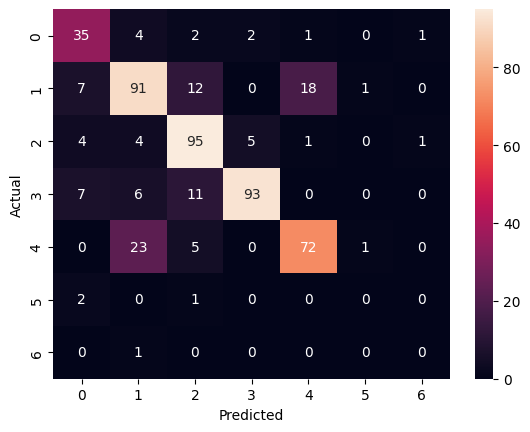

In [106]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lgb_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [107]:
from sklearn.metrics import f1_score

f1_score(y_test, lgb_pred, average="weighted")

0.7642342871007518

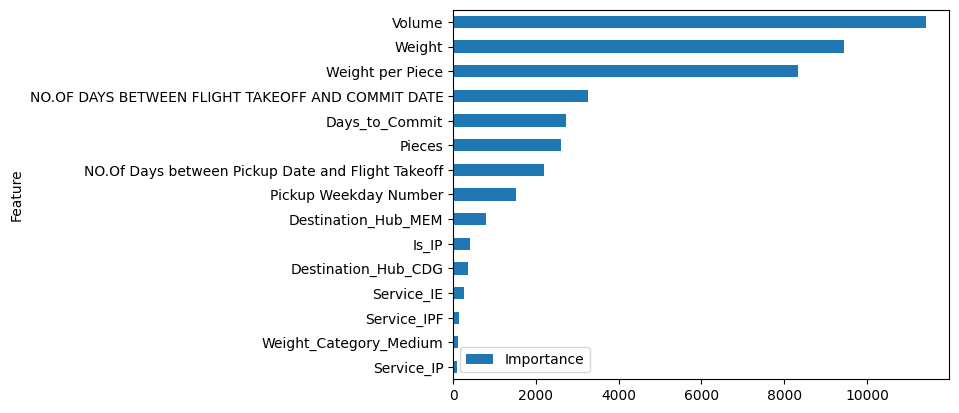

In [108]:
import matplotlib.pyplot as plt

importance.sort_values(by="Importance", ascending=True).tail(15).plot(
    kind="barh", x="Feature", y="Importance"
)
plt.show()

In [109]:
results_df = X_test.copy()
results_df["Actual"] = flight_encoder.inverse_transform(y_test)
results_df["Predicted"] = flight_encoder.inverse_transform(lgb_pred)

# wrong predictions
errors = results_df[results_df["Actual"] != results_df["Predicted"]]

errors.head(20)

,Pieces,Weight,NO.Of Days between Pickup Date and Flight Takeoff,NO.OF DAYS BETWEEN FLIGHT TAKEOFF AND COMMIT DATE,Pickup Weekday Number,Weight per Piece,Volume,Days_to_Commit,Is_IP,Weight_Category_Large,Weight_Category_Medium,Weight_Category_Small,Service_IE,Service_IEF,Service_IP,Service_IPF,Destination_Hub_CDG,Destination_Hub_DXB,Destination_Hub_LHR,Destination_Hub_MEM,Actual,Predicted
509,1.0,6.5,4.0,3.0,3.0,6.500000,2.5200,7.0,1,False,False,True,False,False,True,False,False,False,0,True,QR557,AI179
34,1.0,268.0,3.0,9.0,3.0,268.000000,55.4400,12.0,0,False,True,False,False,False,False,True,False,False,0,True,AI179,QR557
44,1.0,10.1,3.0,3.0,3.0,10.100000,2.7400,6.0,1,False,False,True,False,False,True,False,False,False,0,True,AI179,QR557
1000,4.0,436.0,4.0,3.0,0.0,109.000000,239.9300,7.0,1,False,True,False,False,False,True,False,False,False,0,False,AI179,BA138
1650,1.0,41.0,3.0,6.0,0.0,41.000000,5.9700,9.0,0,False,False,True,True,False,False,False,False,False,0,False,AI179,BA138
1112,6.0,590.1,4.0,2.0,0.0,98.350000,778.3200,6.0,0,False,True,False,False,False,False,True,False,False,0,False,QR557,AI179
1491,1.0,420.0,3.0,3.0,0.0,420.000000,119.1600,6.0,0,False,True,False,False,False,False,True,False,False,0,False,AI179,QR8603
2118,1.0,2.0,10.0,0.0,0.0,2.000000,5.5125,10.0,0,False,False,True,True,False,False,False,False,False,0,False,BA138,AI179
195,7.0,150.0,9.0,0.0,3.0,21.428571,73.4200,9.0,0,False,True,False,True,False,False,False,False,False,0,True,AI179,QR557
2424,1.0,86.5,3.0,5.0,0.0,86.500000,15.0500,8.0,0,False,True,False,False,True,False,False,False,False,0,False,BA138,6E021


In [110]:
processed = prepare_features(shipment_df, feature_columns)

In [111]:
import joblib

joblib.dump(model, "flight_model.pkl")
joblib.dump(flight_encoder, "flight_encoder.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [112]:
model = joblib.load("flight_model.pkl")
encoder = joblib.load("flight_encoder.pkl")
feature_columns = joblib.load("feature_columns.pkl")

In [113]:
# ==============================
# LOAD POD LOOKUP (DO ONCE)
# ==============================
from pod import create_pod_lookup

pod_lookup = create_pod_lookup("POD_FILE.csv")

# IMPORTANT: capacity persists across shipments
capacity_df_copy = capacity_df.copy()


# ==============================
# TEST MULTIPLE SHIPMENTS
# ==============================
num_samples = 5   # change as needed

ready_day_num = 5

for i in range(num_samples):

    print("\n=================================")
    print(f" SHIPMENT {i}")
    print("=================================")

    row = shipment_df.iloc[i]

    # ==============================
    # STEP 1: BUSINESS INPUTS
    # ==============================
    try:
        shipment_weight = row["Weight"]

        # -------- Volume Handling --------
        shipment_volume = row.get("Volume", 0)

        if pd.isna(shipment_volume) or shipment_volume == 0:
            L = row.get("L", 0)
            B = row.get("B", 0)
            H = row.get("H", 0)
            pieces = row.get("Pieces", 1)

            if pd.notna(L) and pd.notna(B) and pd.notna(H) and pieces > 0:
                shipment_volume = (L * B * H * pieces) / 6000
            else:
                shipment_volume = 0

        shipment_volume = max(shipment_volume, 0)

        pickup_day_num = int(row["Pickup Weekday Number"])
        service = row["Service"]
        destination = row["Destination_Hub"]
        origin = row.get("Origin", "BOM")

        is_ip = 1 if service == "IP" else 0

        pickup_date = pd.to_datetime(row["Shipment Pickup Date"])
        commit_date = pd.to_datetime(row["Commit Date"])
        days_to_commit = (commit_date - pickup_date).days

    except Exception as e:
        print("Business input error:", e)
        continue


    # ==============================
    # PRINT SHIPMENT DETAILS
    # ==============================
    print("\n SHIPMENT DETAILS")
    print("------------------------------")
    print("AWB:", row.get("AWB"))
    print("Route:", f"{origin} ➝ {destination}")
    print("Service:", service)
    print("Weight:", shipment_weight)
    print("Volume:", round(shipment_volume, 2))
    print("Pickup Day:", pickup_day_num)
    print("Days to Commit:", days_to_commit)


    # ==============================
    # STEP 2: FEATURE ENGINEERING
    # ==============================
    try:
        row_copy = shipment_df.iloc[[i]].copy()
        row_copy["Volume"] = shipment_volume

        X_input = prepare_features(
            row_copy,
            feature_columns
        )

    except Exception as e:
        print("Feature error:", e)
        continue


    # ==============================
    # STEP 3: ML PREDICTION
    # ==============================
    try:
        df_pred = predict_flights(model, encoder, X_input)

        top3 = apply_business_rules(
            df_pred,
            is_ip=is_ip,
            days_to_commit=days_to_commit
        )

        print("\n Top 3 ML Predictions:")
        print(top3)

    except Exception as e:
        print("Prediction error:", e)
        continue

    # ==============================
    # STEP 4: ROUTING ENGINE
    # ==============================
    try:
        feasible , debug_log = get_feasible_flights(
            top3,
            shipment_weight,
            shipment_volume,
            capacity_df_copy,
            ready_day_num,
            service,
            destination,
            routes_df,
            origin,
            schedule_df,
            pod_lookup,
            days_to_commit=days_to_commit
        )
       
        print("\n DEBUG LOG")
        for log in debug_log:
            print(log)
         
    except Exception as e:
        print("Routing error:", e)
        continue
      
    # ==============================
    # STEP 5: FINAL DECISION LOGIC
    # ==============================
    idx = None
    
    if len(feasible) == 0:
        best_flight = "FedEx"
        flight_day = "Same Day"
        flight_day_num = pickup_day_num

    elif len(feasible) == 1:
        best_flight, idx, flight_day_num, flight_day = feasible[0]

    else:
        feasible_names = [str(f[0]).replace(" ", "").strip() for f in feasible]

        top3_filtered = top3[top3["Flight"].isin(feasible_names)]

        if not top3_filtered.empty:
            best_row = top3_filtered.sort_values("Probability", ascending=False).iloc[0]
            ml_choice = best_row["Flight"]

            ml_match = [f for f in feasible if f[0] == ml_choice]

            if ml_match:
                best_flight, idx, flight_day_num, flight_day = ml_match[0]
            else:
                # ML mismatch → choose earliest
                best_option = sorted(feasible, key=lambda x: x[2])[0]
                best_flight, idx, flight_day_num, flight_day = best_option

        else:
            # ML completely failed → choose earliest
            best_option = sorted(feasible, key=lambda x: x[2])[0]
            best_flight, idx, flight_day_num, flight_day = best_option


    # ==============================
    # STEP 6: CAPACITY UPDATE (ONLY ONCE)
    # ==============================
    if best_flight != "FedEx" and idx is not None:
        capacity_df_copy.loc[idx, "Loaded_So_Far"] += shipment_weight
        capacity_df_copy.loc[idx, "Loaded_Volume"] += shipment_volume


    # ==============================
    # STEP 7: OUTPUT
    # ==============================
    print("\n FINAL DECISION")
    print("------------------------------")

    earliest_day = ((pickup_day_num + 2 - 1) % 7) + 1
    print("Earliest Allowed Day:", earliest_day)

    print("Assigned Flight:", best_flight)
    print("Flight Day:", flight_day)

    delay = flight_day_num - pickup_day_num
    if delay < 0:
        delay += 7

    print("Delay (days):", delay)

    if best_flight == "FedEx":
        print("NO COMMERCIAL FLIGHT FOUND → ASSIGNED TO FEDEX")


print("\n=========== TEST COMPLETE ===========")


 SHIPMENT 0

 SHIPMENT DETAILS
------------------------------
AWB: 397705445605.0
Route: BOM ➝ CDG
Service: IE
Weight: 29.0
Volume: 3.31
Pickup Day: 2
Days to Commit: 9
DEBUG  → model classes: [0 1 2 3 4 5 6]
DEBUG  → encoder classes: ['6E021' 'AI179' 'BA138' 'EK507' 'QR557' 'QR8603' 'QR8605']

 Top 3 ML Predictions:
   Flight  Probability
0   6E021    94.859072
1   AI179     2.885417
2   EK507     2.060594
3   QR557     0.122721
4   BA138     0.064292
5  QR8605     0.004840
6  QR8603     0.003064
Routing error: 'Actual_Date'

 SHIPMENT 1

 SHIPMENT DETAILS
------------------------------
AWB: 887860829300.0
Route: BOM ➝ CDG
Service: IEF
Weight: 75.0
Volume: 39.53
Pickup Day: 2
Days to Commit: 9
DEBUG  → model classes: [0 1 2 3 4 5 6]
DEBUG  → encoder classes: ['6E021' 'AI179' 'BA138' 'EK507' 'QR557' 'QR8603' 'QR8605']

 Top 3 ML Predictions:
   Flight  Probability
0   6E021    73.721522
1   QR557    14.178173
2   AI179     6.636196
3   EK507     5.429953
4   BA138     0.021280
5  QR86